In [215]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.10.0+cu128'

In [216]:
weight = 0.7
bias = 0.3

# Create a linear model
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # add a dimension to the tensor to make it a 2D tensor
y = weight * X + bias

X[:7], X.shape

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200]]),
 torch.Size([50, 1]))

In [217]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

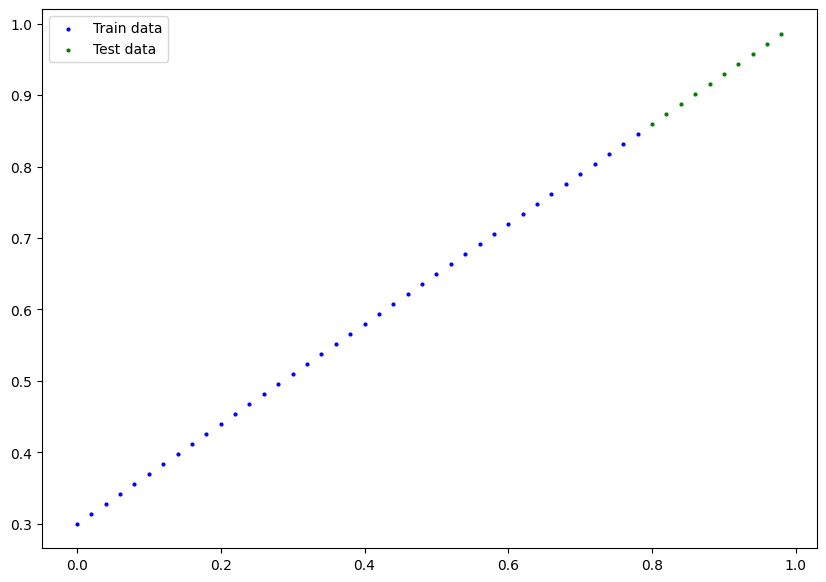

In [218]:
#visualize the data
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Train data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend()

plot_predictions()

In [219]:
# build a linear regression model by hand

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias

In [220]:
model_0 = LinearRegressionModel()
print(list(model_0.parameters()))

print(model_0.state_dict())

[Parameter containing:
tensor([0.1015], requires_grad=True), Parameter containing:
tensor([-0.8431], requires_grad=True)]
OrderedDict([('weight', tensor([0.1015])), ('bias', tensor([-0.8431]))])


In [221]:
print(X_test[:5], y_test[:5])

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800]]) tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160]])


tensor([[-0.7619],
        [-0.7599],
        [-0.7578],
        [-0.7558],
        [-0.7538]])


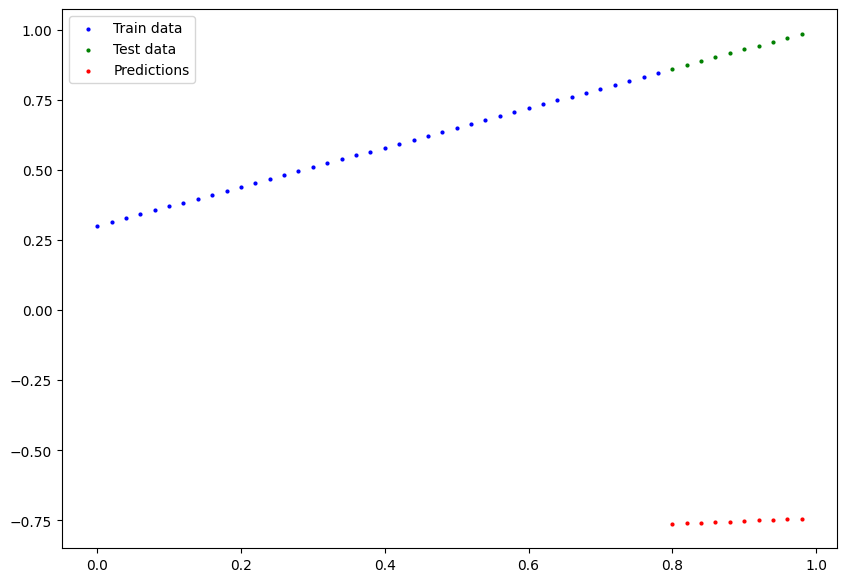

In [222]:
with torch.inference_mode(): #instead of torch.no_grad() we can use torch.inference_mode() which is a more efficient way to disable gradient tracking
    y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)
print(y_preds[:5])

In [223]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

epochs = 385 # loop through the data

for epoch in range(epochs):
    model_0.train() # set the model to training mode. sets all parameters to require gradients

    y_pred = model_0(X_train) # forward pass

    loss = loss_fn(y_pred, y_train) # calculate the loss

    optimizer.zero_grad() # zero the gradients

    loss.backward() # backpropagation

    optimizer.step() # update the parameters

    model_0.eval() # set the model to evaluation mode. disables gradient tracking



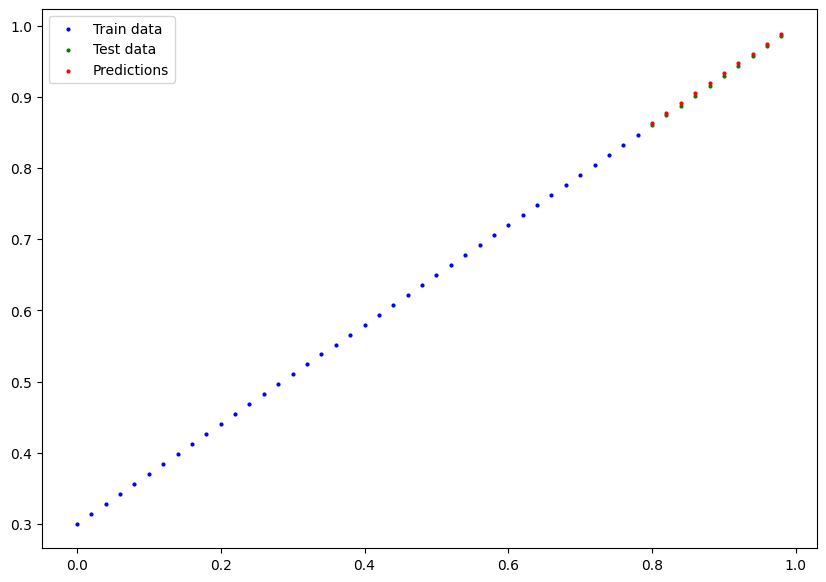

In [224]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

plot_predictions(predictions=y_preds_new)